In [ ]:
# skull_clamp_sim_func.py
"""
Functional simulation of a 3-pin skull clamp.
------------------------------------------------
* forces_N   : list/array of three forces in Newtons          [F1, F2, F3]
* phis_deg   : list/array of three placement angles (deg)     [φ1, φ2, φ3]
* tilts_deg  : list/array of three pin-tilt angles  (deg)     [α1, α2, α3]
               (0 = pure radial; leave None or zeros to ignore tilt)
* skull_geom : dict with keys
       - 'type'  : 'sphere'  or 'ellipsoid'
       - 'R'     : radius (sphere)          --or--
       - 'a','b' : ellipse semi-axes (ellipsoid, top view)
Returns:
    dict with net force, net moment (Mz), depth spread, stability index & label
"""
import numpy as np
# --- geometry helpers -------------------------------------------------
def _surface_point(phi_rad, geom):
    if geom['type'] == 'ellipsoid':
        a, b = geom['a'], geom['b']
        return np.array([a*np.cos(phi_rad), b*np.sin(phi_rad), 0.0])
    # default sphere
    R = geom['R']
    return np.array([R*np.cos(phi_rad), R*np.sin(phi_rad), 0.0])

def _unit_axis(r_hat, tilt_rad):
    ez = np.array([0.0, 0.0, 1.0])
    return -(np.cos(tilt_rad) * r_hat) + np.sin(tilt_rad) * ez

# --- core solver ------------------------------------------------------
def evaluate_clamp(
        forces_N,
        phis_deg,
        tilts_deg=None,
        skull_geom=None,
        k_depth=0.04,             # mm per N (depth proxy)
        Mcrit=50.,                # Nm tolerance for torque
        dcrit=1.0):               # mm tolerance for depth spread
    """
    Compute stability for one configuration.
    """
    forces_N = np.asarray(forces_N, dtype=float)
    phis     = np.deg2rad(phis_deg)
    if tilts_deg is None:
        tilts_deg = [0,0,0]
    tilts    = np.deg2rad(tilts_deg)

    # geometry defaults
    if skull_geom is None:
        skull_geom = dict(type='sphere', R=85.0)  # adult ~85 mm radius

    # 1. coordinates on skull
    r = np.array([_surface_point(phi, skull_geom) for phi in phis])
    r_hat = r / np.linalg.norm(r, axis=1)[:,None]

    # 2. force vectors (radial + tilt)
    F_vec = np.array([
        -F * _unit_axis(r_hat[i], tilts[i])
        for i, F in enumerate(forces_N)
    ])

    # 3. net force & moment about centre
    F_net = F_vec.sum(axis=0)
    M_vec = np.cross(r, F_vec)
    Mz    = M_vec[:,2].sum()          # only z-component drives in-plane rotation

    # 4. depth proxy and spread
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))   # dot product
    delta_d = depths.ptp()    # max-min

    # 5. stability index & label
    SI = np.exp(-abs(Mz)/Mcrit) * np.exp(-delta_d/dcrit)
    if   SI >= 0.80: label = "stabil"
    elif SI >= 0.50: label = "grenzwertig"
    else:            label = "kritisch"

    return dict(
        F_net = F_net,
        Mz    = Mz,
        depths_mm = depths,
        depth_spread_mm = delta_d,
        SI = SI,
        status = label
    )

# ----------------------------------------------------------------------
if __name__ == "__main__":
    # Example 1 – perfectly symmetric
    res1 = evaluate_clamp(
        forces_N=[100,100,100],
        phis_deg=[0,120,240])
    print("Example 1:", res1)

    # Example 2 – forehead overload, no tilt
    res2 = evaluate_clamp(
        forces_N=[130,90,90],
        phis_deg=[0,120,240])
    print("Example 2:", res2)

    # Example 3 – study-style 50°/25° tilts, equal force
    res3 = evaluate_clamp(
        forces_N=[100,100,100],
        phis_deg=[0,120,240],
        tilts_deg=[50,25,25])
    print("Example 3:", res3)


Example 1: {'F_net': array([-1.42108547e-14,  2.84217094e-14,  0.00000000e+00]), 'Mz': 4.547473508864641e-13, 'depths_mm': array([4., 4., 4.]), 'depth_spread_mm': 8.881784197001252e-16, 'SI': 0.99999999999999, 'status': 'stabil'}
Example 2: {'F_net': array([4.00000000e+01, 2.84217094e-14, 0.00000000e+00]), 'Mz': -9.094947017729282e-13, 'depths_mm': array([5.2, 3.6, 3.6]), 'depth_spread_mm': 1.6, 'SI': 0.20189651799465172, 'status': 'kritisch'}
Example 3: {'F_net': array([-2.63520177e+01,  2.84217094e-14, -1.61128097e+02]), 'Mz': 0.0, 'depths_mm': array([2.57115044, 3.62523115, 3.62523115]), 'depth_spread_mm': 1.0540807094004423, 'SI': 0.34851266450442775, 'status': 'kritisch'}


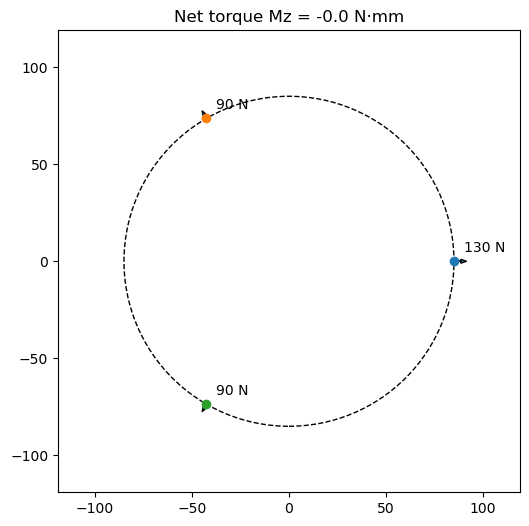

In [ ]:
# Need to re-import numpy and matplotlib after reset
import numpy as np
import matplotlib.pyplot as plt

def evaluate_clamp(forces_N, phis_deg, tilts_deg=None, R=85, k_depth=0.04):
    forces_N = np.asarray(forces_N, dtype=float)
    phis     = np.deg2rad(phis_deg)
    if tilts_deg is None:
        tilts_deg = [0,0,0]
    tilts    = np.deg2rad(tilts_deg)

    r = np.stack([R*np.cos(phis), R*np.sin(phis), np.zeros_like(phis)], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:,None]

    ez = np.array([0,0,1.])
    axis_vec = lambda i: -(np.cos(tilts[i])*r_hat[i]) + np.sin(tilts[i])*ez
    F_vec = np.array([-forces_N[i]*axis_vec(i) for i in range(3)])

    M_vec = np.cross(r, F_vec)
    Mz    = M_vec[:,2].sum()
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
    return r, F_vec, Mz, depths

def plot_clamp(forces, phis, tilts=None, R=85):
    r, F_vec, Mz, depths = evaluate_clamp(forces, phis, tilts, R)
    fig, ax = plt.subplots(figsize=(6,6))
    skull = plt.Circle((0,0), R, fill=False, linestyle='--')
    ax.add_patch(skull)

    for i in range(3):
        ax.plot(r[i,0], r[i,1], marker='o')
        ax.arrow(r[i,0], r[i,1], F_vec[i,0]*0.05, F_vec[i,1]*0.05,
                 head_width=2, length_includes_head=True)
        ax.text(r[i,0]+5, r[i,1]+5, f'{forces[i]} N')

    ax.set_title(f'Net torque Mz = {Mz:.1f} N·mm')
    ax.set_aspect('equal')
    ax.set_xlim(-R*1.4, R*1.4)
    ax.set_ylim(-R*1.4, R*1.4)
    plt.show()

# Demo plot
plot_clamp([130, 90, 90], [0, 120, 240])


In [2]:
phis

[0, 120, 240]

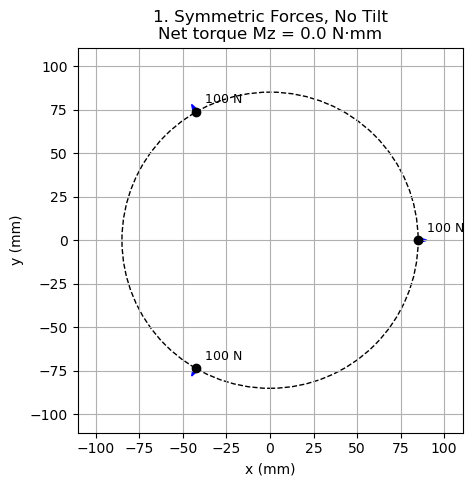

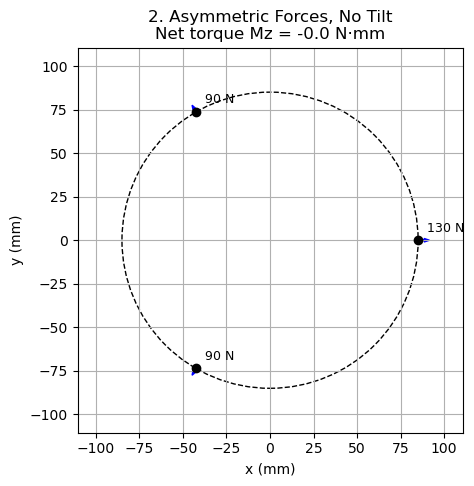

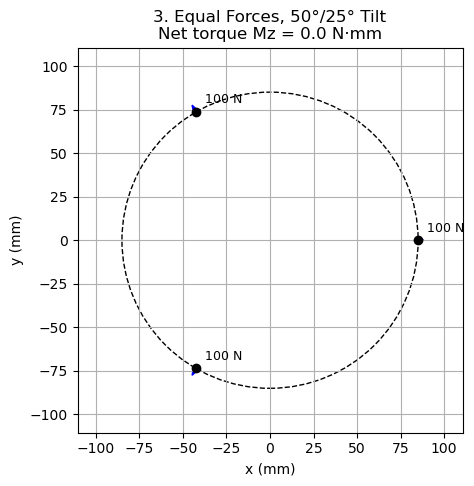

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Core evaluation and plotting functions
def evaluate_clamp(forces_N, phis_deg, tilts_deg=None, R=85, k_depth=0.04):
    forces = np.asarray(forces_N, dtype=float)
    phis = np.deg2rad(phis_deg)
    if tilts_deg is None:
        tilts_deg = [0, 0, 0]
    tilts = np.deg2rad(tilts_deg)

    # Positions on skull surface (top view)
    r = np.stack([R * np.cos(phis), R * np.sin(phis), np.zeros_like(phis)], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]

    ez = np.array([0, 0, 1.0])
    axis_vec = lambda i: -(np.cos(tilts[i]) * r_hat[i]) + np.sin(tilts[i]) * ez

    # Force vectors
    F_vec = np.array([-forces[i] * axis_vec(i) for i in range(3)])

    # Net torque (z-component)
    Mz = np.cross(r, F_vec)[:, 2].sum()

    # Depth proxy
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))

    return r, F_vec, Mz, depths

def plot_clamp_scenario(forces, phis, tilts, title, R=85):
    r, F_vec, Mz, depths = evaluate_clamp(forces, phis, tilts, R)
    fig, ax = plt.subplots(figsize=(5,5))
    circle = plt.Circle((0,0), R, fill=False, linestyle='--')
    ax.add_patch(circle)

    # Plot pins and force vectors
    for i in range(3):
        ax.plot(r[i,0], r[i,1], 'o', color='black')
        ax.arrow(r[i,0], r[i,1], F_vec[i,0]*0.05, F_vec[i,1]*0.05,
                 head_width=2, length_includes_head=True, color='blue')
        ax.text(r[i,0]+5, r[i,1]+5, f'{forces[i]} N', fontsize=9)

    ax.set_aspect('equal')
    ax.set_xlim(-R*1.3, R*1.3)
    ax.set_ylim(-R*1.3, R*1.3)
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_title(f'{title}\nNet torque Mz = {Mz:.1f} N·mm')
    plt.grid(True)
    plt.show()

# Define scenarios
scenarios = [
    ([100, 100, 100], [0,120,240], None, "1. Symmetric Forces, No Tilt"),
    ([130,  90,  90], [0,120,240], None, "2. Asymmetric Forces, No Tilt"),
    ([100, 100, 100], [0,120,240], [50,25,25], "3. Equal Forces, 50°/25° Tilt")
]

# Plot each scenario
for forces, phis, tilts, title in scenarios:
    plot_clamp_scenario(forces, phis, tilts, title)


In [3]:
def evaluate_clamp(
    forces_N,    # [F1, F2, F3] – the three pin forces in Newtons
    phis_deg,    # [φ1, φ2, φ3] – the horizontal placement angles (degrees)
    tilts_deg=None,   # [α1, α2, α3] – optional pin-tilt angles (degrees)
    skull_geom=None,  # dict: {'type':'sphere','R':…} or {'type':'ellipsoid','a':…,'b':…}
    k_depth=0.04,     # conversion factor: force → “penetration depth” (mm per N)
    Mcrit=50.,        # torque scale for the stability index
    dcrit=1.0         # depth-spread scale for the stability index
):
    # 1. Convert inputs to radians and arrays
    forces = np.asarray(forces_N, float)
    phis   = np.deg2rad(phis_deg)
    tilts  = np.deg2rad(tilts_deg or [0,0,0])

    # 2. Choose skull geometry (defaults to a sphere of radius 85 mm)
    if skull_geom is None:
        skull_geom = {'type':'sphere','R':85.}

    # 3. Compute each pin’s (x,y,0) position on the skull surface
    r = np.array([
        _surface_point(phi, skull_geom)
        for phi in phis
    ])  # shape (3,3)
    r_hat = r / np.linalg.norm(r, axis=1)[:,None]

    # 4. Build each pin’s force vector
    #    - purely radial if tilt=0, otherwise tilted by α
    ez = np.array([0.,0.,1.])
    def axis_vec(i):
        return -(np.cos(tilts[i])*r_hat[i]) + np.sin(tilts[i])*ez

    F_vec = np.array([
        -forces[i] * axis_vec(i)
        for i in range(3)
    ])  # shape (3,3)

    # 5. Compute net torque around skull center (only z-component matters)
    M_vec = np.cross(r, F_vec)       # each pin’s moment vector
    Mz    = M_vec[:,2].sum()         # sum of z-components

    # 6. Compute a simple “depth proxy” for each pin
    #    depth_i = k_depth * (force projected radially)
    depths   = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
    delta_d  = depths.ptp()          # max(depths) – min(depths)

    # 7. Combine torque and depth-spread into a single Stability Index (0–1)
    SI = np.exp(-abs(Mz)/Mcrit) * np.exp(-delta_d/dcrit)

    # 8. Qualitative label based on SI thresholds
    if   SI >= 0.80: status = "stabil"
    elif SI >= 0.50: status = "grenzwertig"
    else:            status = "kritisch"

    # 9. Return everything in a dict for easy access
    return {
        'F_net': F_vec.sum(axis=0),
        'Mz': Mz,
        'depths_mm': depths,
        'depth_spread_mm': delta_d,
        'SI': SI,
        'status': status
    }


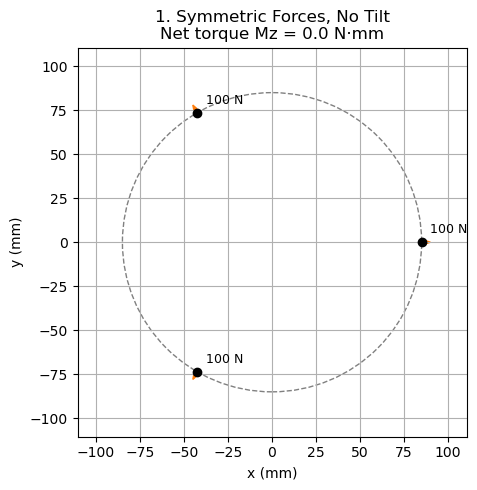

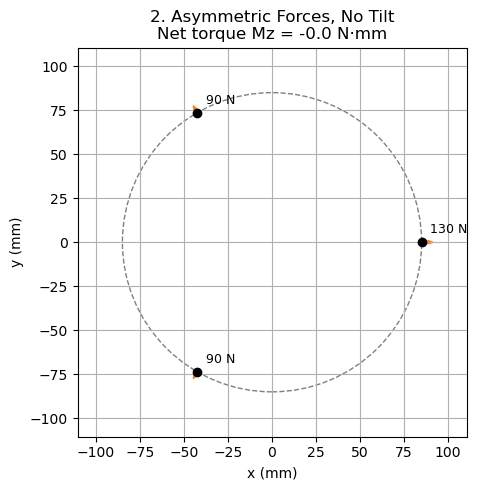

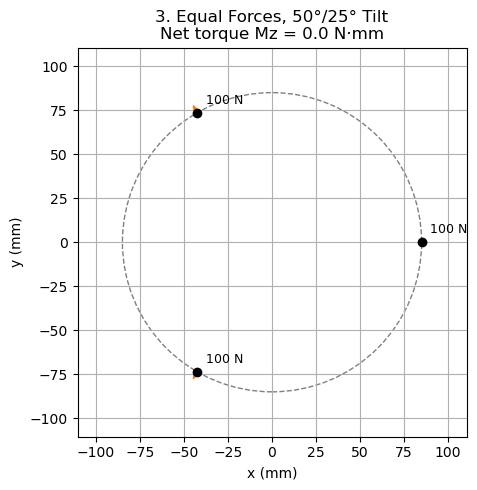

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Core evaluation ──────────────────────────────────────────────────────
def evaluate_clamp(forces_N, phis_deg, tilts_deg=None, R=85, k_depth=0.04):
    """
    forces_N : list of 3 forces in N
    phis_deg : list of 3 azimuthal placement angles in degrees
    tilts_deg: list of 3 tilt angles in degrees (optional; default = [0,0,0])
    R        : skull radius in mm
    k_depth  : conversion factor from radial force to depth proxy (mm per N)
    """
    forces = np.asarray(forces_N, float)
    phis   = np.deg2rad(phis_deg)
    tilts  = np.deg2rad(tilts_deg or [0,0,0])

    # pin positions (x,y,0) on the skull surface
    r = np.stack([R*np.cos(phis), R*np.sin(phis), np.zeros_like(phis)], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:,None]

    ez = np.array([0.0, 0.0, 1.0])
    # combine radial + tilt
    axis_vec = lambda i: -(np.cos(tilts[i])*r_hat[i]) + np.sin(tilts[i])*ez

    # force vectors for each pin
    F_vec = np.array([-forces[i] * axis_vec(i) for i in range(3)])

    # net moment (torque) around z-axis
    Mz = np.cross(r, F_vec)[:,2].sum()

    # penetration-depth proxy per pin
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))

    return r, F_vec, Mz, depths

# ─── Plotting helper ───────────────────────────────────────────────────────
def plot_clamp_scenario(forces, phis, tilts, title, R=85):
    r, F_vec, Mz, depths = evaluate_clamp(forces, phis, tilts, R)
    fig, ax = plt.subplots(figsize=(5,5))

    # draw skull outline
    skull = plt.Circle((0,0), R, fill=False, linestyle='--', color='gray')
    ax.add_patch(skull)

    # plot each pin and its force vector
    for i in range(3):
        ax.plot(r[i,0], r[i,1], 'ko')
        ax.arrow(
            r[i,0], r[i,1],
            F_vec[i,0]*0.05, F_vec[i,1]*0.05,
            head_width=2, length_includes_head=True, color='C1'
        )
        ax.text(r[i,0]+5, r[i,1]+5, f'{forces[i]} N', fontsize=9)

    ax.set_aspect('equal', 'box')
    ax.set_xlim(-R*1.3, R*1.3)
    ax.set_ylim(-R*1.3, R*1.3)
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_title(f'{title}\nNet torque Mz = {Mz:.1f} N·mm')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# ─── Main: three example scenarios ────────────────────────────────────────
if __name__ == "__main__":
    scenarios = [
        ([100, 100, 100], [0,120,240], None,           "1. Symmetric Forces, No Tilt"),
        ([130,  90,  90], [0,120,240], None,           "2. Asymmetric Forces, No Tilt"),
        ([100, 100, 100], [0,120,240], [50,25,25],     "3. Equal Forces, 50°/25° Tilt")
    ]

    for forces, phis, tilts, title in scenarios:
        plot_clamp_scenario(forces, phis, tilts, title)


In [5]:
import numpy as np

def evaluate_with_tracker(
    forces_N, phis_deg, tilts_deg=None,
    tracker_pos=(0.,100.,0.),  # in mm: (x,y,z) of tracker marker
    k_rot=1000.,               # stiffness N·mm per rad
    R=85, k_depth=0.04
):
    # 1. run base evaluation
    r, F_vec, Mz, depths = evaluate_clamp(forces_N, phis_deg, tilts_deg, R, k_depth)

    # 2. compute small rotation angle (rad)
    dphi = Mz / k_rot

    # 3. predicted tracker shift (x,y) from rotation about z
    x, y, z = tracker_pos
    dp_x = -y * dphi
    dp_y =  x * dphi

    TRE = np.hypot(dp_x, dp_y)

    out = dict(
        Mz=Mz,
        rotation_rad=dphi,
        tracker_shift_mm=(dp_x, dp_y),
        TRE_mm=TRE
    )
    return out

# Example usage
res = evaluate_with_tracker(
    forces_N=[130,90,90],
    phis_deg=[0,120,240],
    tracker_pos=(0,120,0),  # marker 120 mm in front of skull center
)
print(res)


{'Mz': -9.094947017729282e-13, 'rotation_rad': -9.094947017729283e-16, 'tracker_shift_mm': (1.0913936421275138e-13, -0.0), 'TRE_mm': 1.0913936421275138e-13}


=== 1. Symmetric, No Tilt ===
SI = 1.00, status = stabil
Slip Risk: False, TRE = 0.00 mm, Alarm: False



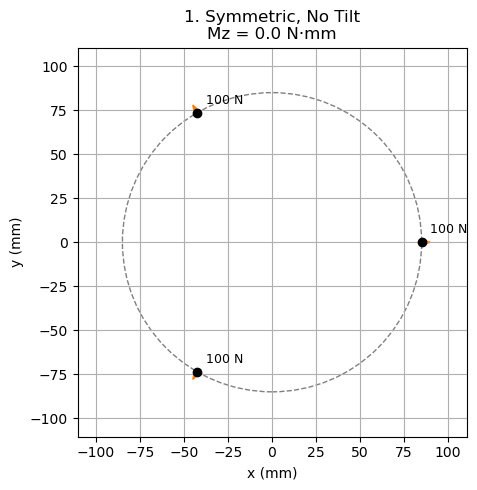

=== 2. Asymmetric, No Tilt ===
SI = 0.20, status = kritisch
Slip Risk: False, TRE = 0.00 mm, Alarm: False



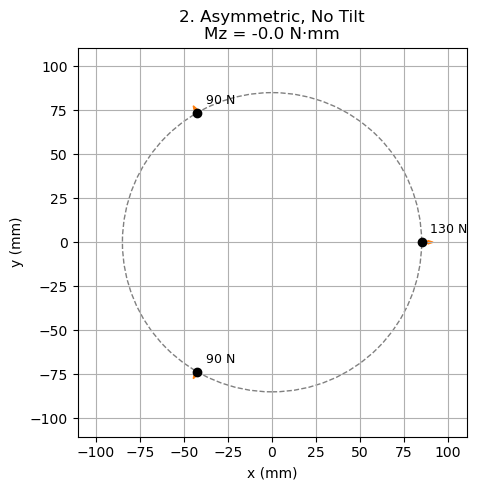

=== 3. Equal, 50°/25° Tilt ===
SI = 0.35, status = kritisch
Slip Risk: False, TRE = 0.00 mm, Alarm: False



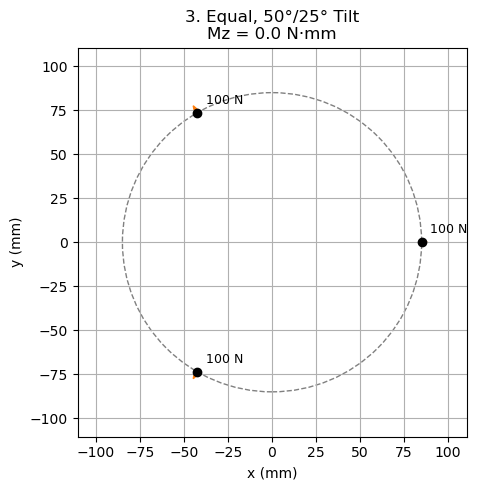

In [6]:
# skull_clamp_full_demo.py
# A comprehensive demo of a simplified skull-clamp stability simulation with visualization.

import numpy as np
import matplotlib.pyplot as plt

def compute_clamp_vectors(forces_N, phis_deg, tilts_deg=None,
                          R=85, k_depth=0.04):
    """
    Compute pin positions, force vectors, net torque, and depth proxy.

    Returns:
        r      : (3,3) array of pin positions [x,y,0]
        F_vec  : (3,3) array of force vectors
        Mz     : scalar net torque about z-axis (N·mm)
        depths : (3,) array of penetration-depth proxies (mm)
    """
    forces = np.asarray(forces_N, float)
    phis = np.deg2rad(phis_deg)
    tilts = np.deg2rad(tilts_deg or [0, 0, 0])

    # pin positions on skull surface (top view circle of radius R)
    r = np.stack([R*np.cos(phis), R*np.sin(phis), np.zeros_like(phis)], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]

    ez = np.array([0.0, 0.0, 1.0])
    def axis_vec(i):
        return -(np.cos(tilts[i]) * r_hat[i]) + np.sin(tilts[i]) * ez

    F_vec = np.array([-forces[i] * axis_vec(i) for i in range(3)])
    Mz = np.cross(r, F_vec)[:, 2].sum()
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))

    return r, F_vec, Mz, depths

def evaluate_clamp(forces_N, phis_deg, tilts_deg=None,
                   skull_geom=None, k_depth=0.04,
                   Mcrit=50.0, M_slip=30.0, dcrit=1.0):
    """
    Compute stability index, slip risk, and more using compute_clamp_vectors.
    """
    # For this simplified demo, ignore skull_geom for vectors
    r, F_vec, Mz, depths = compute_clamp_vectors(forces_N, phis_deg, tilts_deg, k_depth=k_depth)
    # Depth spread
    delta_d = np.ptp(depths)
    # Stability Index
    SI = np.exp(-abs(Mz)/Mcrit) * np.exp(-delta_d/dcrit)
    # Qualitative label
    if SI >= 0.80:
        status = 'stabil'
    elif SI >= 0.50:
        status = 'grenzwertig'
    else:
        status = 'kritisch'
    # Slip alarm
    slip_risk = abs(Mz) > M_slip

    return {
        'F_net': F_vec.sum(axis=0),
        'Mz': Mz,
        'depths_mm': depths,
        'depth_spread_mm': delta_d,
        'SI': SI,
        'status': status,
        'slip_risk': slip_risk
    }

def evaluate_with_tracker(forces_N, phis_deg, tilts_deg=None,
                          tracker_pos=(0.0, 120.0, 0.0),
                          k_rot=1000.0, TRE_thresh=0.5, **kwargs):
    """
    Extend clamp evaluation by estimating tracker registration error (TRE).
    """
    base = evaluate_clamp(forces_N, phis_deg, tilts_deg, **kwargs)
    Mz = base['Mz']
    dphi = Mz / k_rot
    x, y, _ = tracker_pos
    dp_x = -y * dphi
    dp_y =  x * dphi
    TRE = np.hypot(dp_x, dp_y)
    tre_alarm = TRE > TRE_thresh
    base.update({
        'rotation_rad': dphi,
        'tracker_shift_mm': (dp_x, dp_y),
        'TRE_mm': TRE,
        'tre_alarm': tre_alarm
    })
    return base

def plot_clamp_scenario(forces, phis, tilts, title, R=85):
    """
    Visualize a single clamp configuration: skull, pins, and force vectors.
    """
    r, F_vec, Mz, depths = compute_clamp_vectors(forces, phis, tilts, R)
    fig, ax = plt.subplots(figsize=(5,5))
    circle = plt.Circle((0,0), R, fill=False, linestyle='--', color='gray')
    ax.add_patch(circle)
    for i in range(3):
        ax.plot(r[i,0], r[i,1], 'ko')
        ax.arrow(r[i,0], r[i,1],
                 F_vec[i,0]*0.05, F_vec[i,1]*0.05,
                 head_width=2, length_includes_head=True, color='C1')
        ax.text(r[i,0]+5, r[i,1]+5, f'{forces[i]} N', fontsize=9)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-R*1.3, R*1.3)
    ax.set_ylim(-R*1.3, R*1.3)
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_title(f'{title}\nMz = {Mz:.1f} N·mm')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    scenarios = [
        ([100, 100, 100], [0,120,240], None,       "1. Symmetric, No Tilt"),
        ([130,  90,  90], [0,120,240], None,       "2. Asymmetric, No Tilt"),
        ([100, 100, 100], [0,120,240], [50,25,25], "3. Equal, 50°/25° Tilt")
    ]
    for forces, phis, tilts, title in scenarios:
        res = evaluate_with_tracker(forces, phis, tilts,
                                    tracker_pos=(0,120,0))
        print(f"=== {title} ===")
        print(f"SI = {res['SI']:.2f}, status = {res['status']}")
        print(f"Slip Risk: {res['slip_risk']}, TRE = {res['TRE_mm']:.2f} mm, Alarm: {res['tre_alarm']}\n")
        plot_clamp_scenario(forces, phis, tilts, title)
